# **RAG System For Intelligent Robotics Cours**e

## (1.a) Importing modules and Dowload Dataset

In this section we setup all the modules and the dataset for the rag.

In [1]:
# Dowload all needed modules.
!pip install transformers sentence-transformers faiss-cpu hf_transfer pandas matplotlib seaborn mdclense

In [2]:
# Import all necessary modules.
import json
import os
from mdclense.parser import MarkdownParser
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from collections import Counter
from transformers import AutoModelForCausalLM, AutoTokenizer
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import time

# Needed for faster dowloads (not sure)
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

In [3]:
# Here we download all the necessary files from our git repository.

# Download the chapters and store them into 'data' folder.
!curl -s https://api.github.com/repos/Ultimi-Sumiti/RAG-system/contents/data/raw_data/chapters \
| grep "download_url" \
| cut -d '"' -f 4 \
| xargs -n 1 curl -L -O --create-dirs --output-dir data/raw_data

# Dowload quesions and answers.
!curl -L -O https://raw.githubusercontent.com/Ultimi-Sumiti/RAG-system/main/data/questions_answers.json --output-dir data

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  5184  100  5184    0     0  65098      0 --:--:-- --:--:-- --:--:-- 65620
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  4133  100  4133    0     0  51786      0 --:--:-- --:--:-- --:--:-- 52316
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  8822  100  8822    0     0   111k      0 --:--:-- --:--:-- --:--:--  113k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1708  100  1708    0     0  21225      0 --:--:-- --:--:-- --:--:-- 21350
  % Total    % Received % Xferd  Average Speed   Tim

In [ ]:
# Uncomment the following lines if you want to store the
# llm model (that we will use later) into your personal gdrive.
# NOTE that the first time you dowload the model, it will take some time.

cache_dir = None
from google.colab import drive
drive.mount('/content/drive')
# Create a cache folder in your Drive.
cache_dir = "/content/drive/MyDrive/hf_model_cache"
os.makedirs(cache_dir, exist_ok=True)
# Set hugging face cache dir.
os.environ["HF_HOME"] = cache_dir

MessageError: Error: credential propagation was unsuccessful

## (1.b) Preprocessing: creating the knowledge base

Our dataset is composed by 10 markdown files, each file contains a single chapter.
Those file are notes from the course of Intelligent Robotics (a course from UNIPD).

In this section we perform the following operations:

1. Merge the content of all markdown files into a single variable.
2. Parse the entire document: remove markdown tags and store raw document to disk.
3. Split the raw document into smaller chunks
    - Chunk size = 150 words
    - Overlapping percentage = 10%
4. Store chunks into a json file.

In [4]:
# Global vars.
RAW_DATA_DIR = "./data/raw_data/"
KB_JSON = "./data/kb_docs.json"

def create_overlapping_chunks(word_list, chunk_size, overlap_pct):
    """ Given a list of strings it returns a list of ovelapping chunks """
    # Calculate the number of overlapping words.
    overlap_count = int(chunk_size * overlap_pct)
    # Create the chunks.
    step = chunk_size - overlap_count
    chunks = [
        word_list[i : i + chunk_size]
        for i in range(0, len(word_list), step)
    ]
    output = ["".join(x + " " for x in ls) for ls in chunks]
    return output

In [5]:
# Create a list containing the text of each chapter file.
ls = []
for file in os.listdir(RAW_DATA_DIR):
    # File path.
    fp = os.path.join(RAW_DATA_DIR, file)
    # Open file and append content to list.
    with open(fp, 'r') as f:
        t = f.read()
        ls.append(t)

# Merge the content of each chapter into a single string.
text = "".join([x for x in ls])
print("Document lenght (chars):", len(text))

Document lenght (chars): 65374


In [6]:
# Remove markdown tags from the text.
parser = MarkdownParser()
clean = parser.parse(text)
print("Cleaned document length (chars):", len(clean))
ls_clean = clean.split()
print("Number of words in the document:", len(ls_clean))
# Store cleaned text to disk.
with open("./data/cleaned_raw_text.txt", 'w') as f:
    f.write(clean)

Cleaned document length (chars): 58805
Number of words in the document: 8525


In [7]:
# Create the chunks.
chunk_size = 150
overlap_pct = 0.1

# Get list of chunks.
ls_docs = create_overlapping_chunks(ls_clean, chunk_size=chunk_size, overlap_pct=overlap_pct)
# Print some stats...
non_overlap = len(ls_clean) // chunk_size
print("Total blocks (non overlapping):", non_overlap)
print("Total blocks (overlapping)", len(ls_docs))

# Store chunks into a json file.
kb = [{"id":i, "text": text} for i, text in enumerate(ls_docs)]
with open(KB_JSON, 'w') as f:
    json.dump(kb, f, indent=4)

Total blocks (non overlapping): 56
Total blocks (overlapping) 64


##  (1.c) Dataset Profiling

In this section we plot some statistics about the our documents.

In [8]:
# Define raw data input
file_path = './data/cleaned_raw_text.txt'
SENTENCE_EMBEDDING_MODEL_ID = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(SENTENCE_EMBEDDING_MODEL_ID)
with open(file_path, 'r') as f:
    raw_text = f.read()

In [9]:
# Some basic stats on raw dataset.
char_count = len(raw_text)
words = raw_text.split()
word_count = len(words)
tokens = tokenizer.encode(raw_text, add_special_tokens=False)
total_tokens = len(tokens)
unique_tokens = len(set(tokens))

print(f"### Raw Dataset Stats ###")
print(f"Total Characters: {char_count}")
print(f"Total Words:      {word_count}")
print(f"Total Tokens:     {total_tokens}")
print(f"Vocabulary Size:  {unique_tokens}")

Token indices sequence length is longer than the specified maximum sequence length for this model (12706 > 512). Running this sequence through the model will result in indexing errors


### Raw Dataset Stats ###
Total Characters: 58805
Total Words:      8525
Total Tokens:     12706
Vocabulary Size:  2429



### Chunking Stats ###
Number of chunks: 64


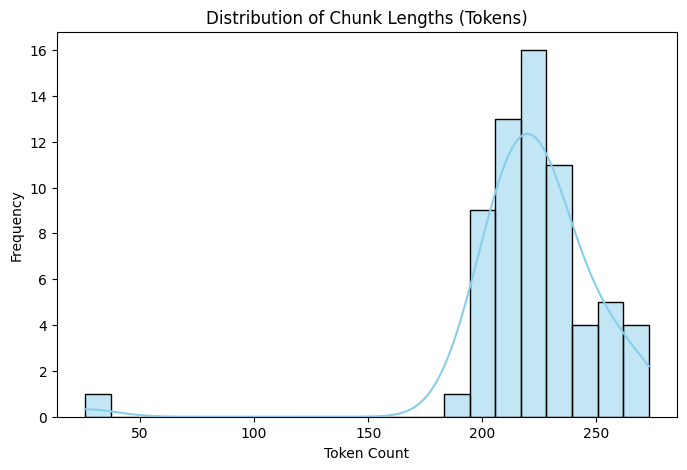

In [11]:
# Chunks stats.
with open(KB_JSON, 'r') as f:
    chunks = json.load(f)

chunk_lengths = [len(tokenizer.encode(c["text"])) for c in chunks]
df_chunks = pd.DataFrame(chunk_lengths, columns=['token_length'])
print(f"\n### Chunking Stats ###")
print(f"Number of chunks: {len(chunks)}")

plt.figure(figsize=(8, 5))
sns.histplot(df_chunks['token_length'], kde=True, color='skyblue')
plt.title('Distribution of Chunk Lengths (Tokens)')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.show()
plt.close()

The last chunk contains fewer tokens than the others.
Apart from this final chunk, all remaining chunks are nicely distributed.

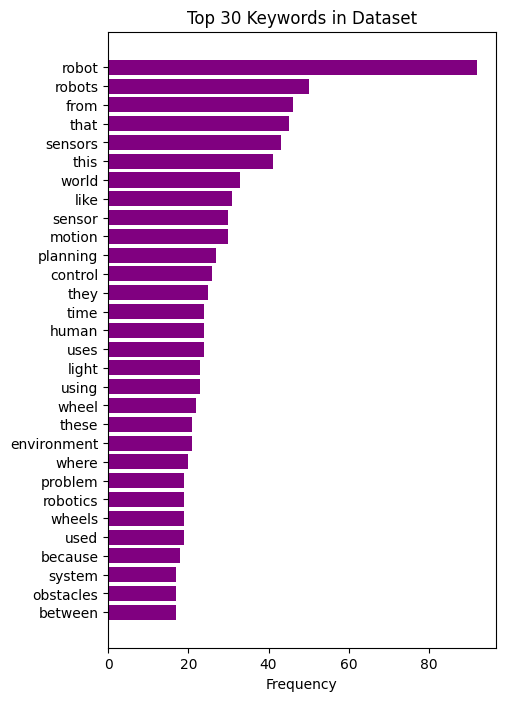

In [12]:
# Simple cleanup for keyword frequency.
clean_text = re.sub(r'[^\w\s]', '', raw_text.lower())
stop_words = {'the', 'and', 'to', 'of', 'a', 'in', 'is', 'it', 'for', 'on', 'with', 'as'}
filtered_words = [w for w in clean_text.split() if w not in stop_words and len(w) > 3]
word_counts = Counter(filtered_words)

# Display table.
df_freq = pd.DataFrame(word_counts.items(), columns=['Word', 'Frequency'])
df_freq = df_freq.sort_values(by='Frequency', ascending=False).reset_index(drop=True)
#print("### Top 30 Keywords in Dataset ###")
#print(df_freq.head(30))

# Print figure.
plt.figure(figsize=(5, 8))
plt.barh(df_freq.head(30)['Word'], df_freq.head(30)['Frequency'], color='purple')
plt.title('Top 30 Keywords in Dataset')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.show()
plt.close()

We can see that many words are related to *robotics* such that: `robot`, `sensor`, `motion`, `planning`, etc.

# Generate answers

**About the generation process.** We decided to test our model on 50 queries. We've created 5 question for each chapter stored in `./data/raw_data/` folder. Each question is paired with a golden answer. The queries and answers are stored in `./data/questions_answers.json`.

**How did we get the queries/answers?**  The queries were generated by [NotebookLM](https://notebooklm.google/): we gave as input the chapters in `./data/raw_data/` and we asked to provide 5 questions for each one. After that we've asked it to generate the (gold) answers.

**Generation process steps.**

- Read knowledge base and encode all documents.
- Create the vector database with the documents embeddings.
- Load the model (Qwen3-8B) and retreive all queries (from disk).
- Encode all the queries $q$ and search the top-k document similar to the query context
- Create a prompt for each query and store the result given by the model
- Finally we store the rag answers to disk (`./output_rag_answers.json`).
- Make the evaluation between the output of the generator model and the gold answers
- Finally we store the rag answers to disk (`./output_evaluations.json`).

## (2) Sentence embeddings




In [15]:
# Encode our knowledge base using a model for sentence embedding.

# Open our .json file with all the chunks and save it into a list of dictionaries
with open(KB_JSON, 'r') as f:
    chunks = json.load(f)

print("Some Chunks: ")
for i,a in enumerate(chunks):
  if i < 5:
    print(a)
  else:
    break

print("Number of chunks", len(chunks))

# Create a list containing all the strings inside the 'text' folder for each chunk
TEXT_CHUNKS = [c['text'] for c in chunks]

# Set our encoder model and encode the list of strings of the chunk
encoder = SentenceTransformer(SENTENCE_EMBEDDING_MODEL_ID)
chunks_embd = encoder.encode(TEXT_CHUNKS)
# Print the dimension of our encoded vectors, we expect a 2D numpy array of shape (64, 384) by structural properties of all-MiniLM-L6-v2
print(chunks_embd.shape)

Some Chunks: 
{'id': 0, 'text': 'Software Architectures for robotics and robotics paradigms Robot Architectures The Hierarchical Paradigm (Classic AI) The Cycle: This paradigm, dominant from the late 60s to the 80s, operates on a strict serial sequence: SENSE $\\rightarrow$ PLAN $\\rightarrow$ ACT. Characteristics: It focuses heavily on "planning." The robot perceives the world to update an internal global model, reasons upon that model to generate a plan, and then executes it. Examples: Shakey (1967): The first AI robot, developed by SRI. It used the STRIPS algorithm to plan actions based on a logical description of the world (predicates like INROOM or PUSHABLE). The Monkey and Banana Problem: A classic test case where a planner must deduce how to move a box to reach a banana. It highlights the reliance on a static, fully described world. Limitations (Why it failed): The Closed World Assumption: It assumes the internal model is perfect and contains everything relevant. It '}
{'id': 1,

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(64, 384)


## (3) Build the retriver

In [16]:
# Use Faiss to build the Retriver, that is obtaining the top k index of chuncks for the relative query


Q_A_JSON = "./data/questions_answers.json"

# Dimension  384
d = chunks_embd.shape[1]

# Build the index object, it encapsulates the set of database vectors, it requires the size of chuncks that it needs to process
index = faiss.IndexFlatL2(d)
print(index.is_trained)
# Add vectors embeddings of the chunks to the index
index.add(chunks_embd)
print(index.ntotal)

# We want to see top-k nearest neighbors (top-k docs to retrive) related to a specific query
k = 3

# Read the Q&A .json file and store into a list
with open(Q_A_JSON, 'r') as f:
    q_a_docs = json.load(f)

# Save in lists queries and answers generated by NotebookLM
QUERIES = [c['question'] for c in q_a_docs]
GOLD_ANSWERS = [c['answer'] for c in q_a_docs]


# Embedded also the queries thanks to our encoder model
queries_embd = encoder.encode(QUERIES)
#print(queries_embd)
print("Shape of embedded queries: ",queries_embd.shape)

# D is the distance , I is the index of the vector emmbedding
# Exploit index object to make the search of the top-k chuncks (which represent the top k-docs) to retrive
# In practice inside the I matrix we have store the mapping necessary to link a query q with its top-k neighboors (aka the retrived chunks)
D, I = index.search(queries_embd, k)

# Top 3 chunk for the first 5 queries (out of 50)
print("Top 3 chunks for first 5 queries \n", I[:5])






True
64
Shape of embedded queries:  (50, 384)
Top 3 chunks for first 5 queries 
 [[0 1 3]
 [1 0 3]
 [2 4 3]
 [3 1 4]
 [4 3 2]]


In [17]:
# Print some information to see the structure of I and D matrices and the mapping with top k chunks (retrived documents)
print("First row of I: ", I[0], '\n')


print("First top-k chunk for first query: ", chunks[I[0][0]],'\n')
print("Second top-k chunk for first query: ", chunks[I[0][1]],'\n')
print("Third top-k chunk for first query: ",chunks[I[0][2]],'\n')

print("Distance bewtween first top-k chunck and first query: ", D[0][0],'\n')
print("Distance bewtween second top-k chunck and first query:", D[0][1],'\n')
print("Distance bewtween third top-k chunck and first query:", D[0][2],'\n')


First row of I:  [0 1 3] 

First top-k chunk for first query:  {'id': 0, 'text': 'Software Architectures for robotics and robotics paradigms Robot Architectures The Hierarchical Paradigm (Classic AI) The Cycle: This paradigm, dominant from the late 60s to the 80s, operates on a strict serial sequence: SENSE $\\rightarrow$ PLAN $\\rightarrow$ ACT. Characteristics: It focuses heavily on "planning." The robot perceives the world to update an internal global model, reasons upon that model to generate a plan, and then executes it. Examples: Shakey (1967): The first AI robot, developed by SRI. It used the STRIPS algorithm to plan actions based on a logical description of the world (predicates like INROOM or PUSHABLE). The Monkey and Banana Problem: A classic test case where a planner must deduce how to move a box to reach a banana. It highlights the reliance on a static, fully described world. Limitations (Why it failed): The Closed World Assumption: It assumes the internal model is perfect 

In [18]:
# Load the model for the Generator
GENERATOR_MODEL_ID = "Qwen/Qwen3-8B"
model_qwen = AutoModelForCausalLM.from_pretrained(
    GENERATOR_MODEL_ID,
    device_map="auto",
)
# Load the tokenizer for the model
tokenizer_qwen = AutoTokenizer.from_pretrained(GENERATOR_MODEL_ID)


Current model requires 512 bytes of buffer for offloaded layers, which seems does not fit any GPU's remaining memory. If you are experiencing a OOM later, please consider using offload_buffers=True.


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

## (4) Create the prompts and feed the model

In [ ]:
system_context = """You are a helpful assistant.
Use the retrieved documents to answer the question as best as you can.
If you don't know the answer, say you don't know.
Your answer are short and concise"""


# For each query build the prompt and send it to the model
RESULTS = []
for i, (query,idx) in enumerate(zip(QUERIES,I)):
    print("Query",i, ": ", query)

    # Save the specific top k document retrived before for that specific query
    TOP_CHUNKS = [TEXT_CHUNKS[i] for i in idx]

    # Building the prompt for a speicific query : top_chunks (retrived information) + query
    # .join() method is Python’s standard way to glue a list of strings together
    user_prompt = f"""Here is some useful context: {'\n'.join(TOP_CHUNKS)}\n\n Here is the query: {query}
    """

    # Build our input following the rules of the library hugging face
    # We pass not just a block of text but a structured 'conversation'
    messages = [
        {"role": "system", "content": system_context}, # Context
        {"role": "user", "content": user_prompt} # Prompt question + retrived informations
    ]

    # Tokenization with Qwen of our prompt passing the messages
    inputs = tokenizer_qwen.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        enable_thinking=False # Because qwen is a reasoning model and uses a lot of RAM
    ).to(model_qwen.device)

    # Send the prompt to Qwen
    outputs = model_qwen.generate(**inputs, max_new_tokens=40)
    # Decoding with the tokenizer to obtain the real "readable" output
    answer = tokenizer_qwen.decode(outputs[0][inputs["input_ids"].shape[-1]:])

    # Build the list with the final results appended as a dictionary
    RESULTS.append({'answer': answer})
    print("Answer",i, ": ", answer)


Query 0 :  Why did the classic Hierarchical Paradigm (Sense-Plan-Act) ultimately fail to handle real-world robotic applications effectively, especially regarding the 'Closed World Assumption'?
Answer 0 :  The classic Hierarchical Paradigm (Sense-Plan-Act) ultimately failed to handle real-world robotic applications effectively due to the **Closed World Assumption**, which assumes the internal model is perfect and contains
Query 1 :  How does the concept of 'emergent behavior' in the Reactive Paradigm challenge the traditional AI notion that robots require complex internal reasoning to perform sophisticated tasks?


In [ ]:
# Save the RESULTS in a .json file
RESULTS_JSON = './output_rag_answers.json'

res_dic = q_a_docs
# Add a new key folder in the dictionaries
for res, dic in zip(RESULTS, res_dic):
    dic["ragAns"] = res

with open(RESULTS_JSON, 'w') as f:
    json.dump(res_dic, f, indent=4)

print(f"RAG answers saved to {RESULTS_JSON}")

## (5) Evaluation

Notice how the approach of building a prompt for each GOLD_ANSWER - RESULT comparison instead of building a unique prompt with all the pairs it's a method less prone to hitting context window limits (which can be an issue with models like Qwen)

In [ ]:
system_context = """You are a helpful assistant.
I will give you some GOLD_ANSWER (your ground truth) and some RESULTS of
the same queries, your task is to evaluate the RESULTS in comparison with the GOLD ANSWER.
I ask you to answer me with an evaluation within 1 to 5 range (where 1 stands for very bad and 5 stands
for perfect) and a really short motivation
about your grading of maximum one sentence.
Your answer must built with the following structure: [ grade : motivation ] all in the same line"""

EVALUATIONS = []

for g,r in zip(GOLD_ANSWERS, RESULTS):

  user_prompt = f"""This is the GOLD_ANSWER: {g} \n\n Here is the RESULT obtained prompting an Llm: {r['answer']}
    """

  messages = [
        {"role": "system", "content": system_context}, # Context
        {"role": "user", "content": user_prompt} # GOLD_ANSWER + RESULT from Qwen
    ]

  # Tokenization with Qwen of our prompt passing the messages
  inputs = tokenizer_qwen.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        enable_thinking=False # Because qwen is a reasoning model and uses a lot of RAM
    ).to(model_qwen.device)

  # Send the prompt to Qwen
  outputs = model_qwen.generate(**inputs, max_new_tokens=40, eos_token_id=tokenizer_qwen.eos_token_id)
  answer = tokenizer_qwen.decode(outputs[0][inputs["input_ids"].shape[-1]:])

  # Build the list with the final evaluations
  EVALUATIONS.append({'evaluation': answer})
  print('Evaluation: ', answer)

In [ ]:
# Save the EVALUATIONS in a .json file
EVALUATIONS_JSON = './output_evaluations.json'

with open(EVALUATIONS_JSON , 'w') as f:
    json.dump(EVALUATIONS, f, indent=4)

print(f"RAG answers saved to {EVALUATIONS_JSON }")